In [1]:
import pandas as pd
import shutil
import os
import numpy as np
import matplotlib.pyplot as plt
import onekey_algo.custom.components as okcomp
from onekey_algo import get_param_in_cwd

plt.rcParams['figure.dpi'] = 300

task = get_param_in_cwd('task_column') or 'label'
bst_model = get_param_in_cwd('sel_model') or 'LR'
model_names = ['Clinic Signature', 'Rad Signature', 'Nomogram']
labels = [task]
label_data_ = pd.read_csv('clinic_sel.csv')[['ID', 'label']]
label_data_ = label_data_.dropna(axis=0)

ids = label_data_['ID']
print(label_data_.columns)
label_data = label_data_[['ID'] + labels]
label_data

Index(['ID', 'label'], dtype='object')


,ID,label
0,1.nii.gz,1
1,2.nii.gz,1
2,3.nii.gz,1
3,4.nii.gz,1
4,5.nii.gz,1
...,...,...
232,234.nii.gz,1
233,235.nii.gz,1
234,236.nii.gz,1
235,237.nii.gz,1


# 训练集-Nomogram

In [2]:
import pandas as pd

Clinic_results = pd.merge(pd.read_csv(f'./results/Clinic_{bst_model}_train.csv', header=0), label_data, on='ID', how='inner')
Rad_results = pd.merge(pd.read_csv(f'./results/Rad_{bst_model}_train.csv', header=0), label_data, on='ID', how='inner')

ALL_results = pd.merge(Clinic_results, Rad_results, on='ID', how='inner')
ALL_results.columns = ['ID', '-0', 'Clinic_Sig', task, '-00', 'Rad_Sig', '-l']

ALL_results = ALL_results.dropna(axis=1)
ALL_results

,ID,-0,Clinic_Sig,label,-00,Rad_Sig,-l
0,1.nii.gz,0.438,0.562,1,0.372,0.628,1
1,2.nii.gz,0.394,0.606,1,0.315,0.685,1
2,3.nii.gz,0.304,0.696,1,0.257,0.743,1
3,4.nii.gz,0.438,0.562,1,0.293,0.707,1
4,5.nii.gz,0.725,0.275,1,0.505,0.495,1
...,...,...,...,...,...,...,...
184,233.nii.gz,0.402,0.598,1,0.395,0.605,1
185,234.nii.gz,0.702,0.298,1,0.591,0.409,1
186,236.nii.gz,0.532,0.468,1,0.551,0.449,1
187,237.nii.gz,0.304,0.696,1,0.362,0.638,1


In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from onekey_algo.custom.components import metrics

model = LogisticRegression(random_state=0)
# model = SVC(probability=True, random_state=0)
data_x = ALL_results[['Clinic_Sig', 'Rad_Sig']]
data_y = ALL_results[task]
model.fit(data_x, data_y)
results = model.predict_proba(data_x)
results = pd.DataFrame(results, index=ALL_results['ID'], columns=[f'{task}-0', f'{task}-1']).reset_index()
results.to_csv('./results/Nomo_train.csv', index=False, header=True)
pd.DataFrame([metrics.analysis_pred_binary(ALL_results[task], results[f'{task}-1'])], 
                  columns=['acc', 'auc', '95%CI', 'Sensitivity', 'Specificity', 'PPV', 'NPV', 'Precision', 'Recall', 'F1', 'Threshold'])

,acc,auc,95%CI,Sensitivity,Specificity,PPV,NPV,Precision,Recall,F1,Threshold
0,0.873,0.935,"[0.901926, 0.968822]",0.821,0.914,0.885,0.865,0.885,0.821,0.852,0.493


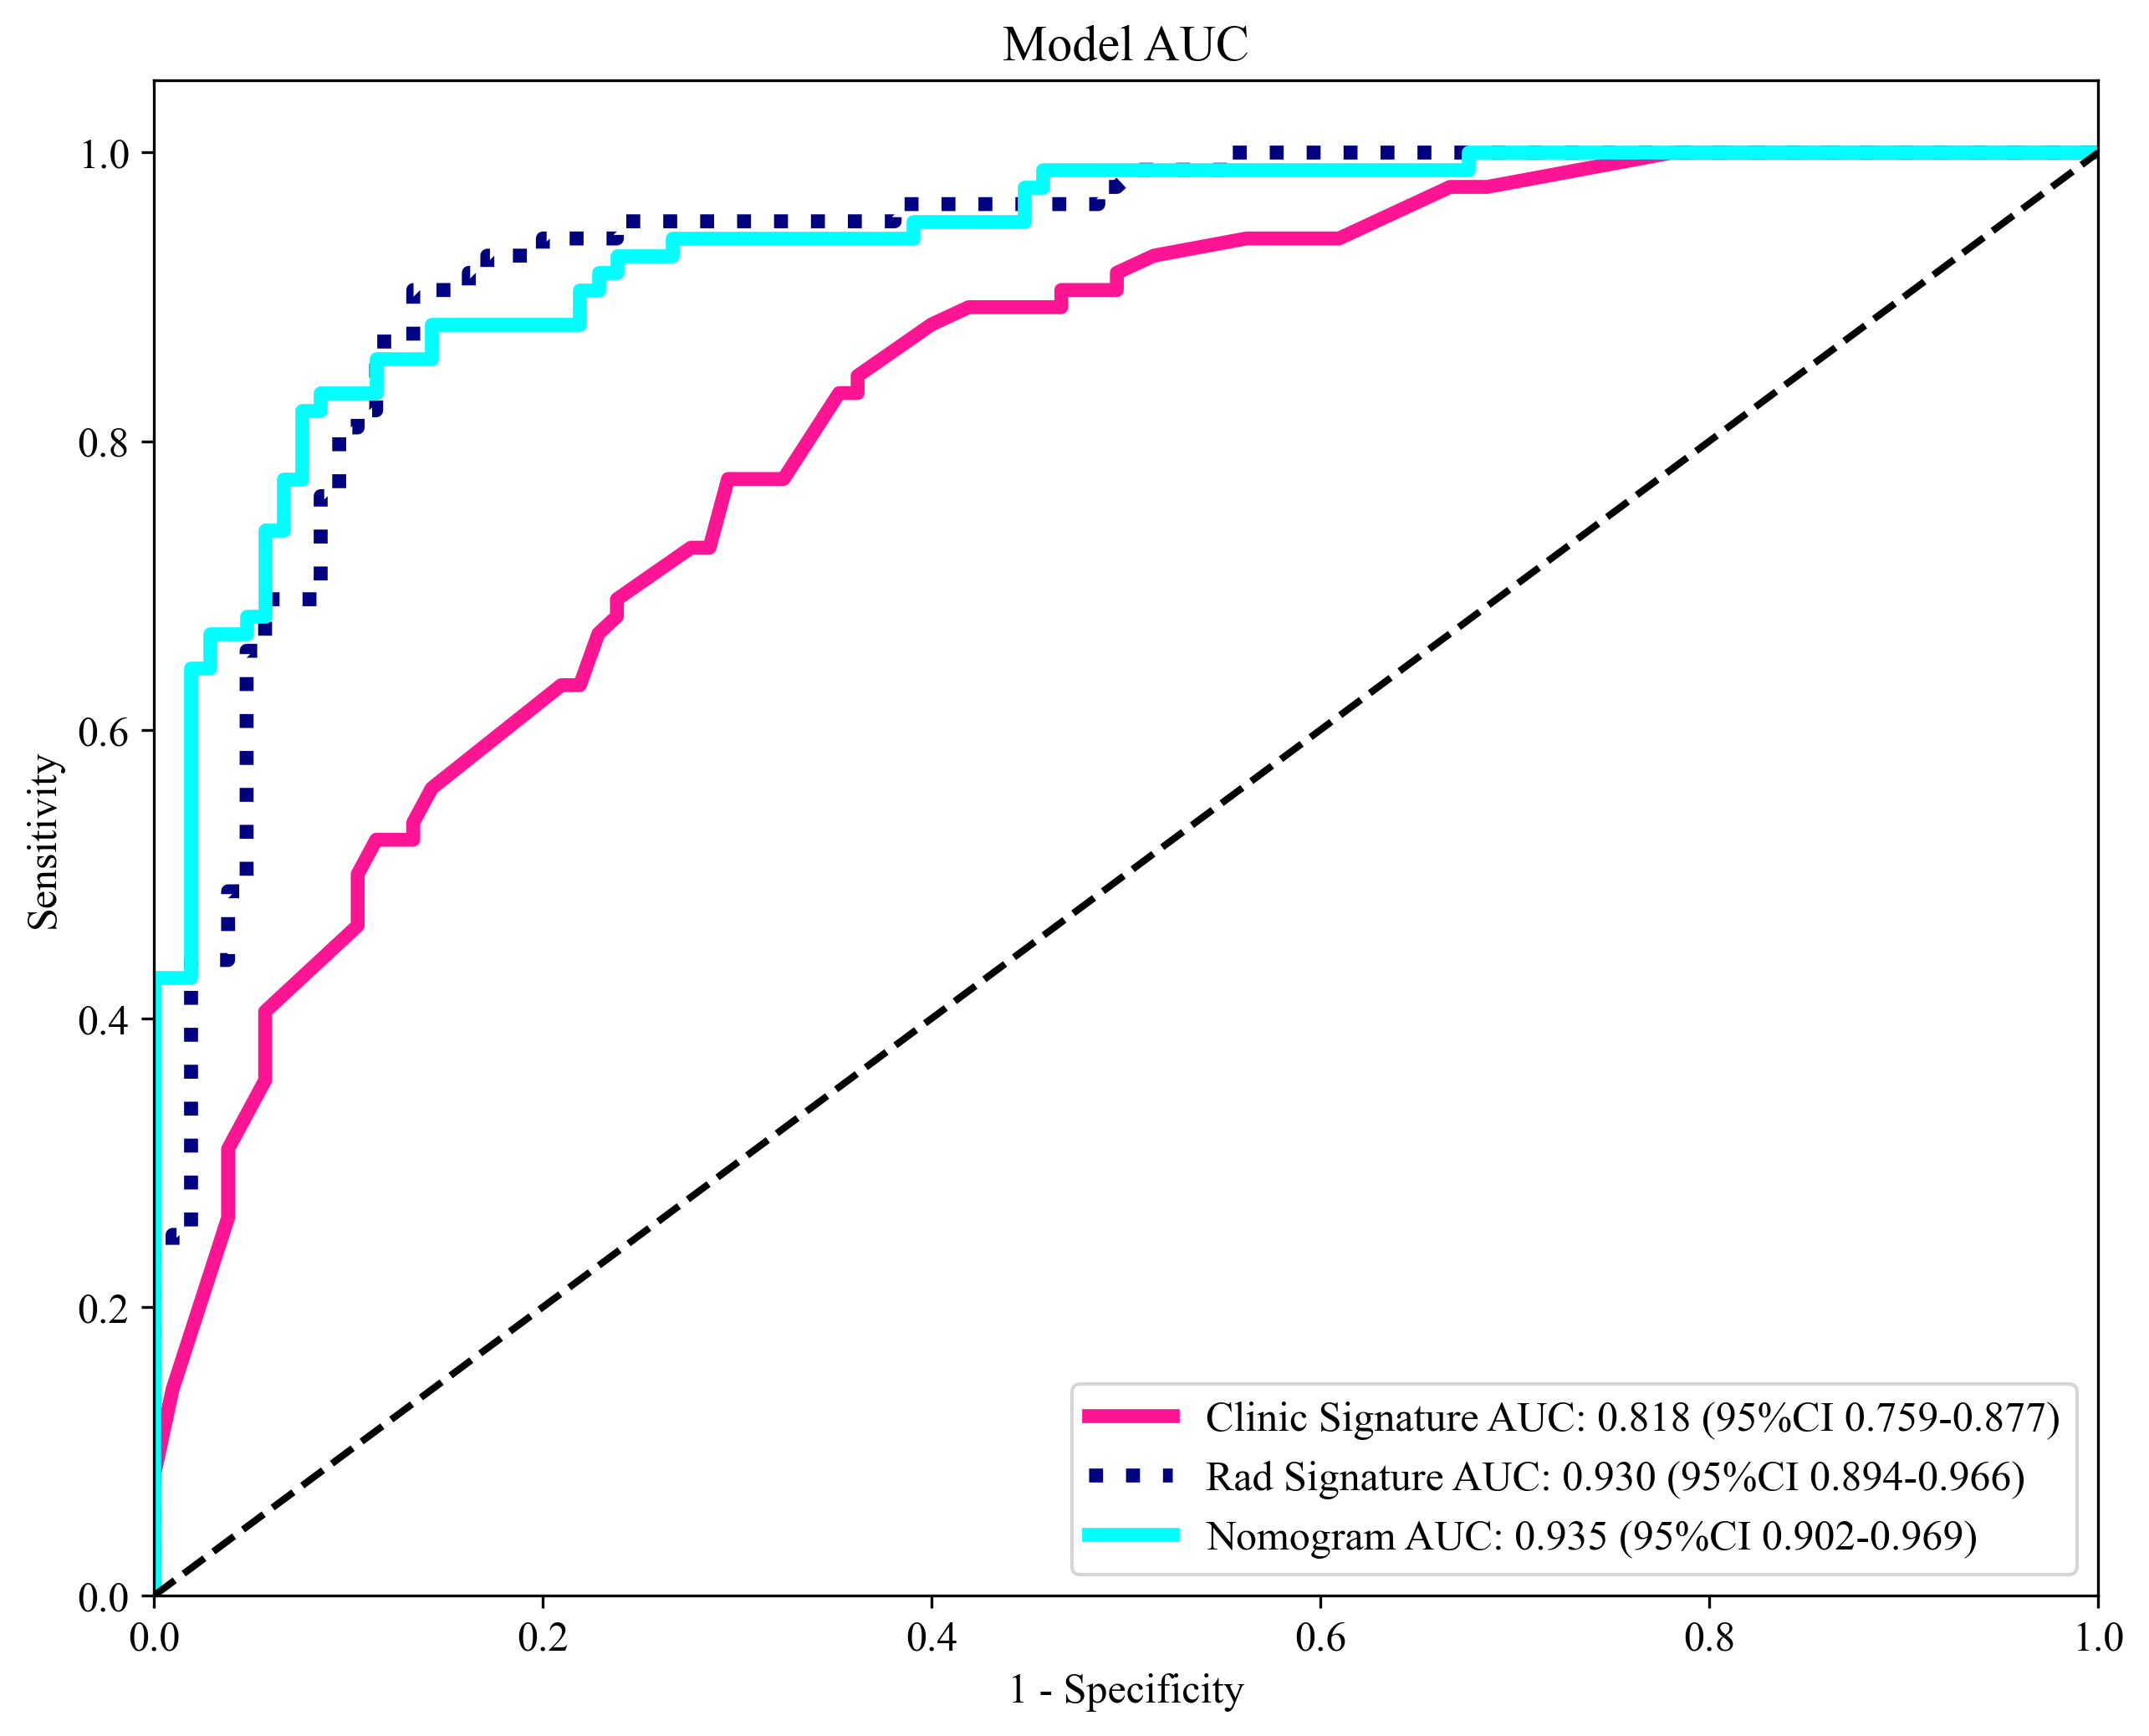

In [4]:
pred_column = [f'{task}-0', f'{task}-1']
Nomo_results = pd.merge(pd.read_csv('./results/Nomo_train.csv', header=0), label_data, on='ID', how='inner')
gt = [np.array(d) for d in [Clinic_results[labels], Rad_results[labels], Nomo_results[labels]]]
pred_train = [np.array(d) for d in [Clinic_results[pred_column], Rad_results[pred_column], Nomo_results[pred_column]]]
okcomp.comp1.draw_roc(gt, pred_train, labels=model_names,  
                      title=f"Model AUC")
plt.savefig(f'img/train_auc.svg')

In [5]:
from onekey_algo.custom.components.metrics import analysis_pred_binary
metric = []
for mname, y, score in zip(model_names, gt, pred_train):
    # 计算验证集指标
    acc, auc, ci, tpr, tnr, ppv, npv, precision, recall, f1, thres = analysis_pred_binary(y, score)
    ci = f"{ci[0]:.4f} - {ci[1]:.4f}"
    metric.append((mname, acc, auc, ci, tpr, tnr, ppv, npv, precision, recall, f1, thres, f"Train"))
pd.DataFrame(metric, index=None, columns=['Signature', 'Accuracy', 'AUC', '95% CI', 'Sensitivity', 'Specificity', 
                                          'PPV', 'NPV', 'Precision', 'Recall', 'F1','Threshold', 'Cohort'])

,Signature,Accuracy,AUC,95% CI,Sensitivity,Specificity,PPV,NPV,Precision,Recall,F1,Threshold,Cohort
0,Clinic Signature,0.725,0.818,0.7591 - 0.8765,0.833,0.638,0.648,0.827,0.648,0.833,0.729,0.413,Train
1,Rad Signature,0.878,0.930,0.8945 - 0.9662,0.893,0.867,0.843,0.910,0.843,0.893,0.867,0.449,Train
2,Nomogram,0.873,0.935,0.9019 - 0.9688,0.821,0.914,0.885,0.865,0.885,0.821,0.852,0.493,Train


In [6]:
from onekey_algo.custom.components.delong import delong_roc_test

Nomo_results.columns = ['ID', '-00000', 'Nomogram', '-llll']
results = pd.merge(ALL_results, Nomo_results, on='ID', how='inner')

delong = []
delong.append([delong_roc_test(results[task], results[f'Nomogram'], results[f'Clinic_Sig'])[0][0],
              delong_roc_test(results[task], results[f'Nomogram'], results[f'Rad_Sig'])[0][0], 'Train'])
pd.DataFrame(delong, columns=['Nomogram Vs Clinic', 'Nomogram Vs Rad', 'cohort'])

,Nomogram Vs Clinic,Nomogram Vs Rad,cohort
0,8.863e-07,0.62,Train


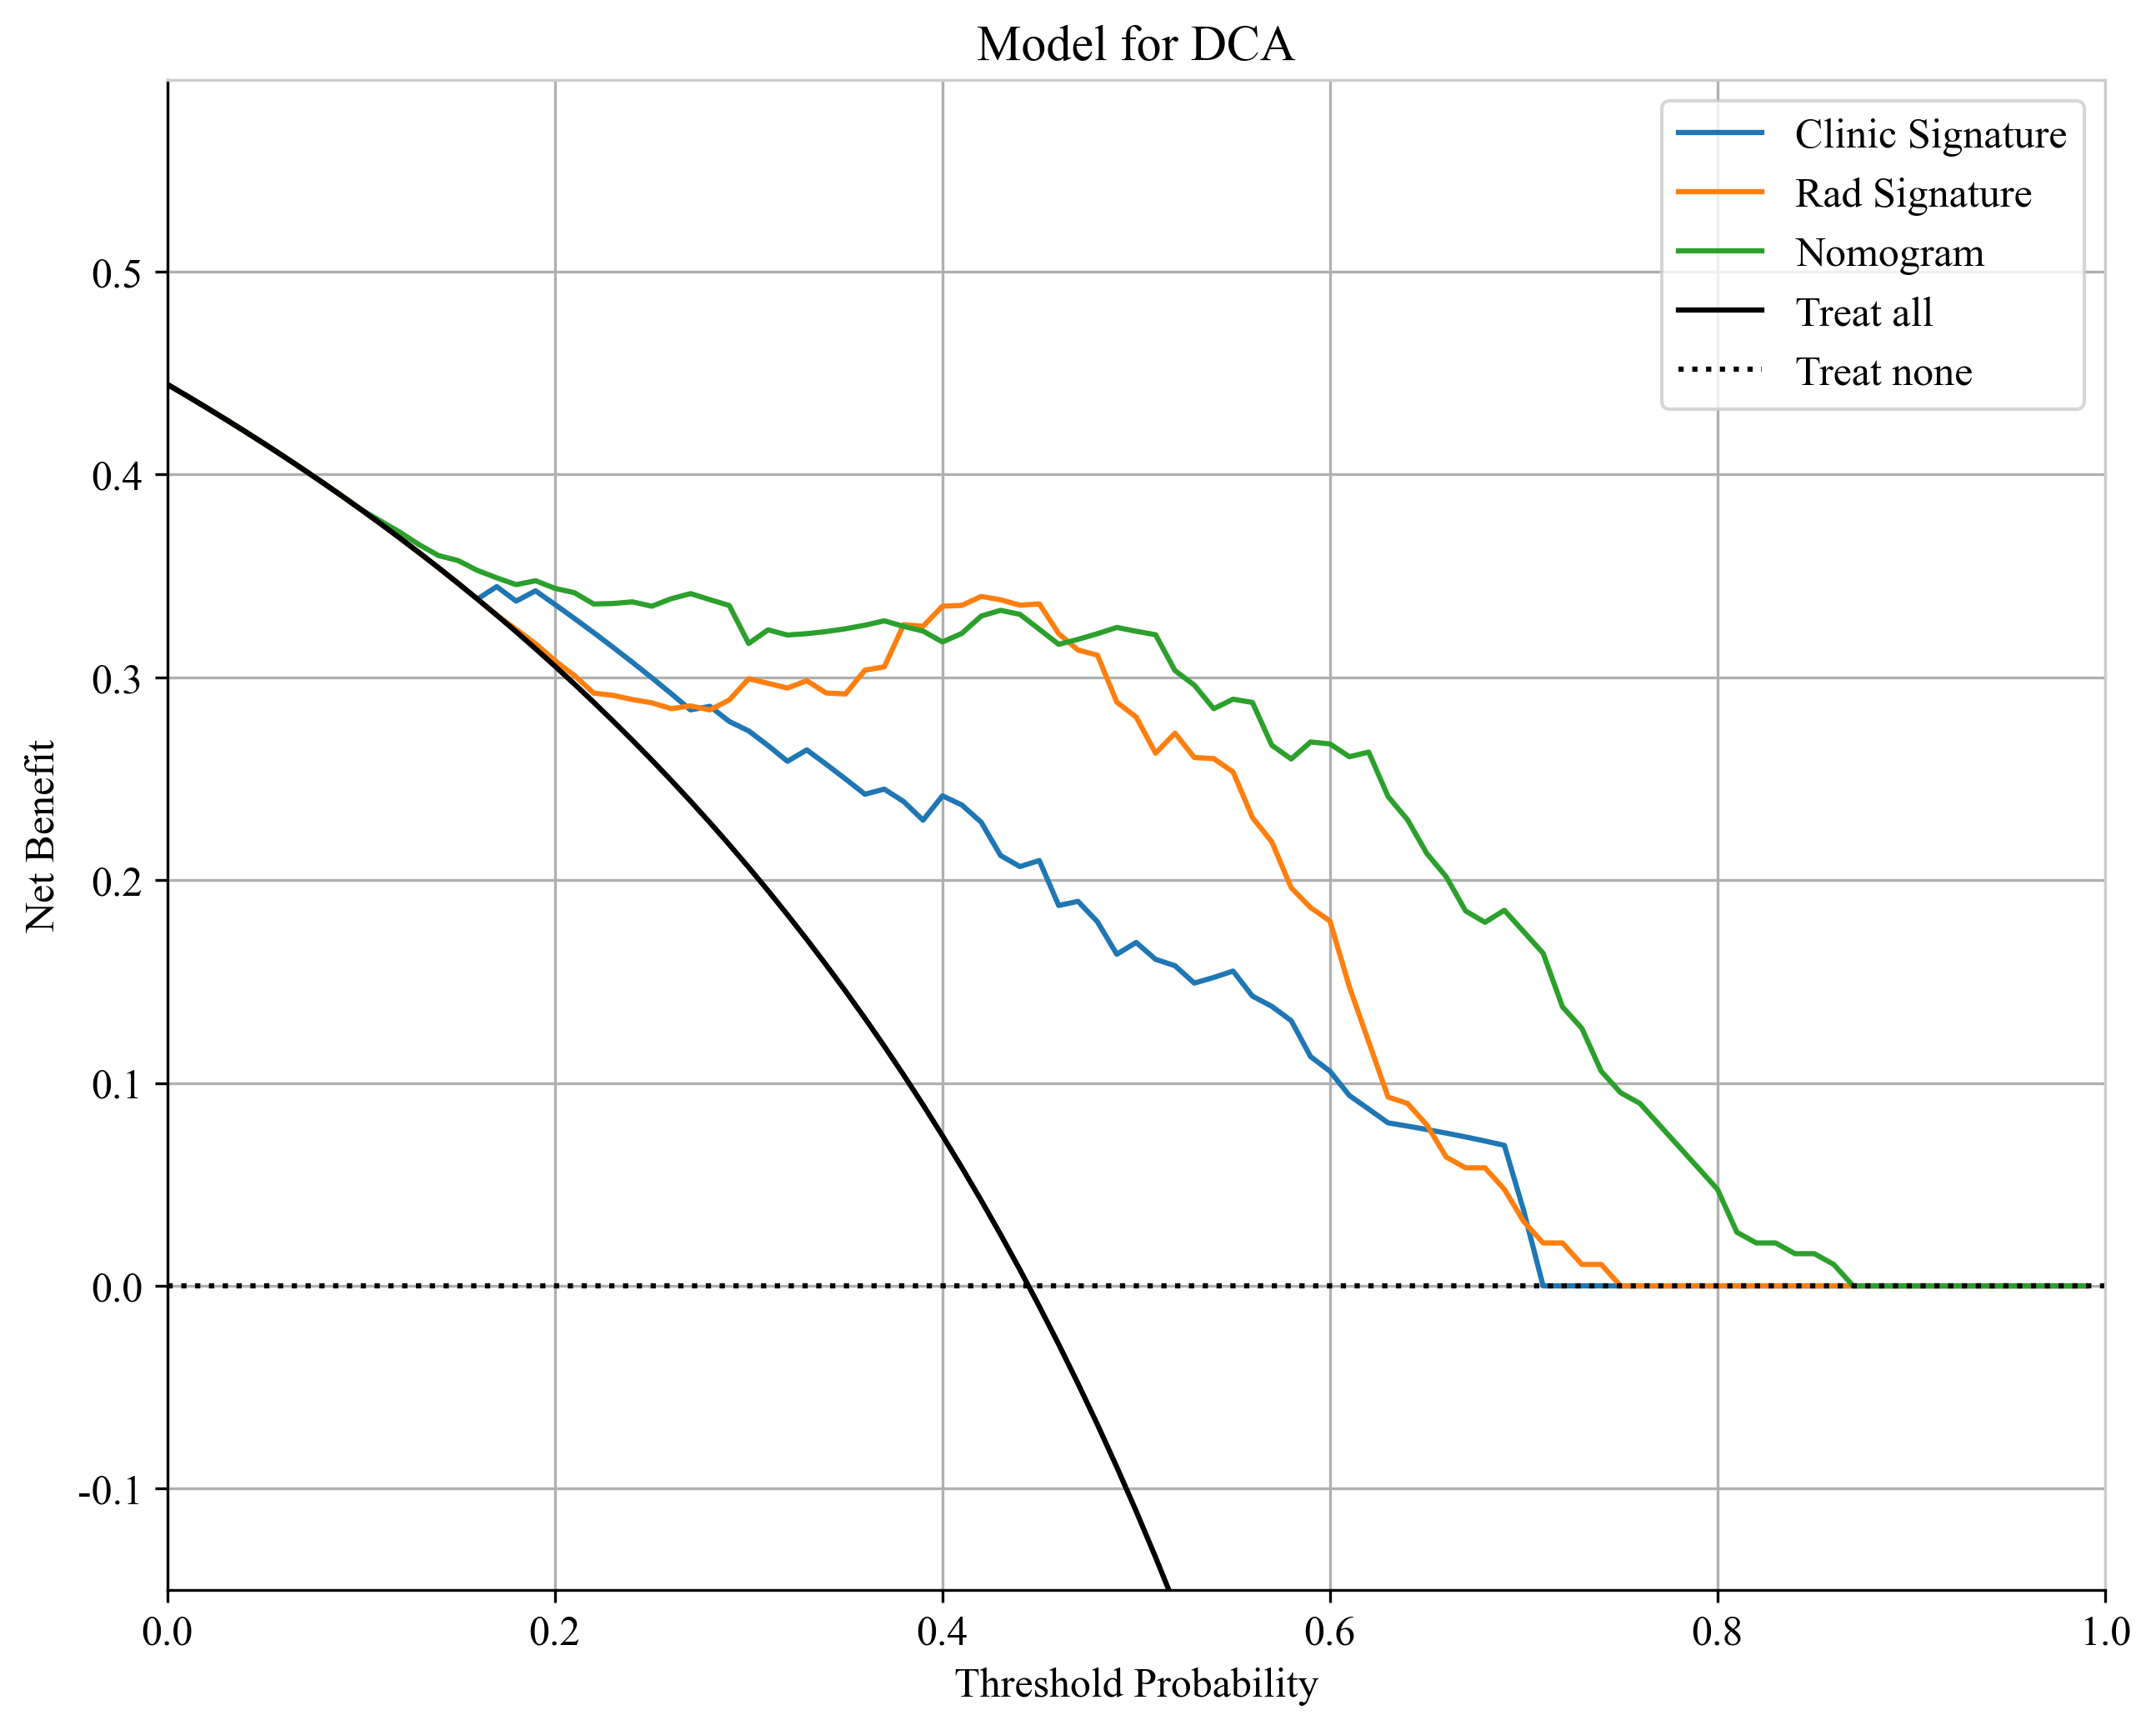

In [7]:
from onekey_algo.custom.components.comp1 import plot_DCA
plot_DCA([results[f'Clinic_Sig'], results[f'Rad_Sig'], results[f'Nomogram']], 
         results[task], title=f'Model for DCA', labels=model_names)
plt.savefig(f'img/train_dca.svg')

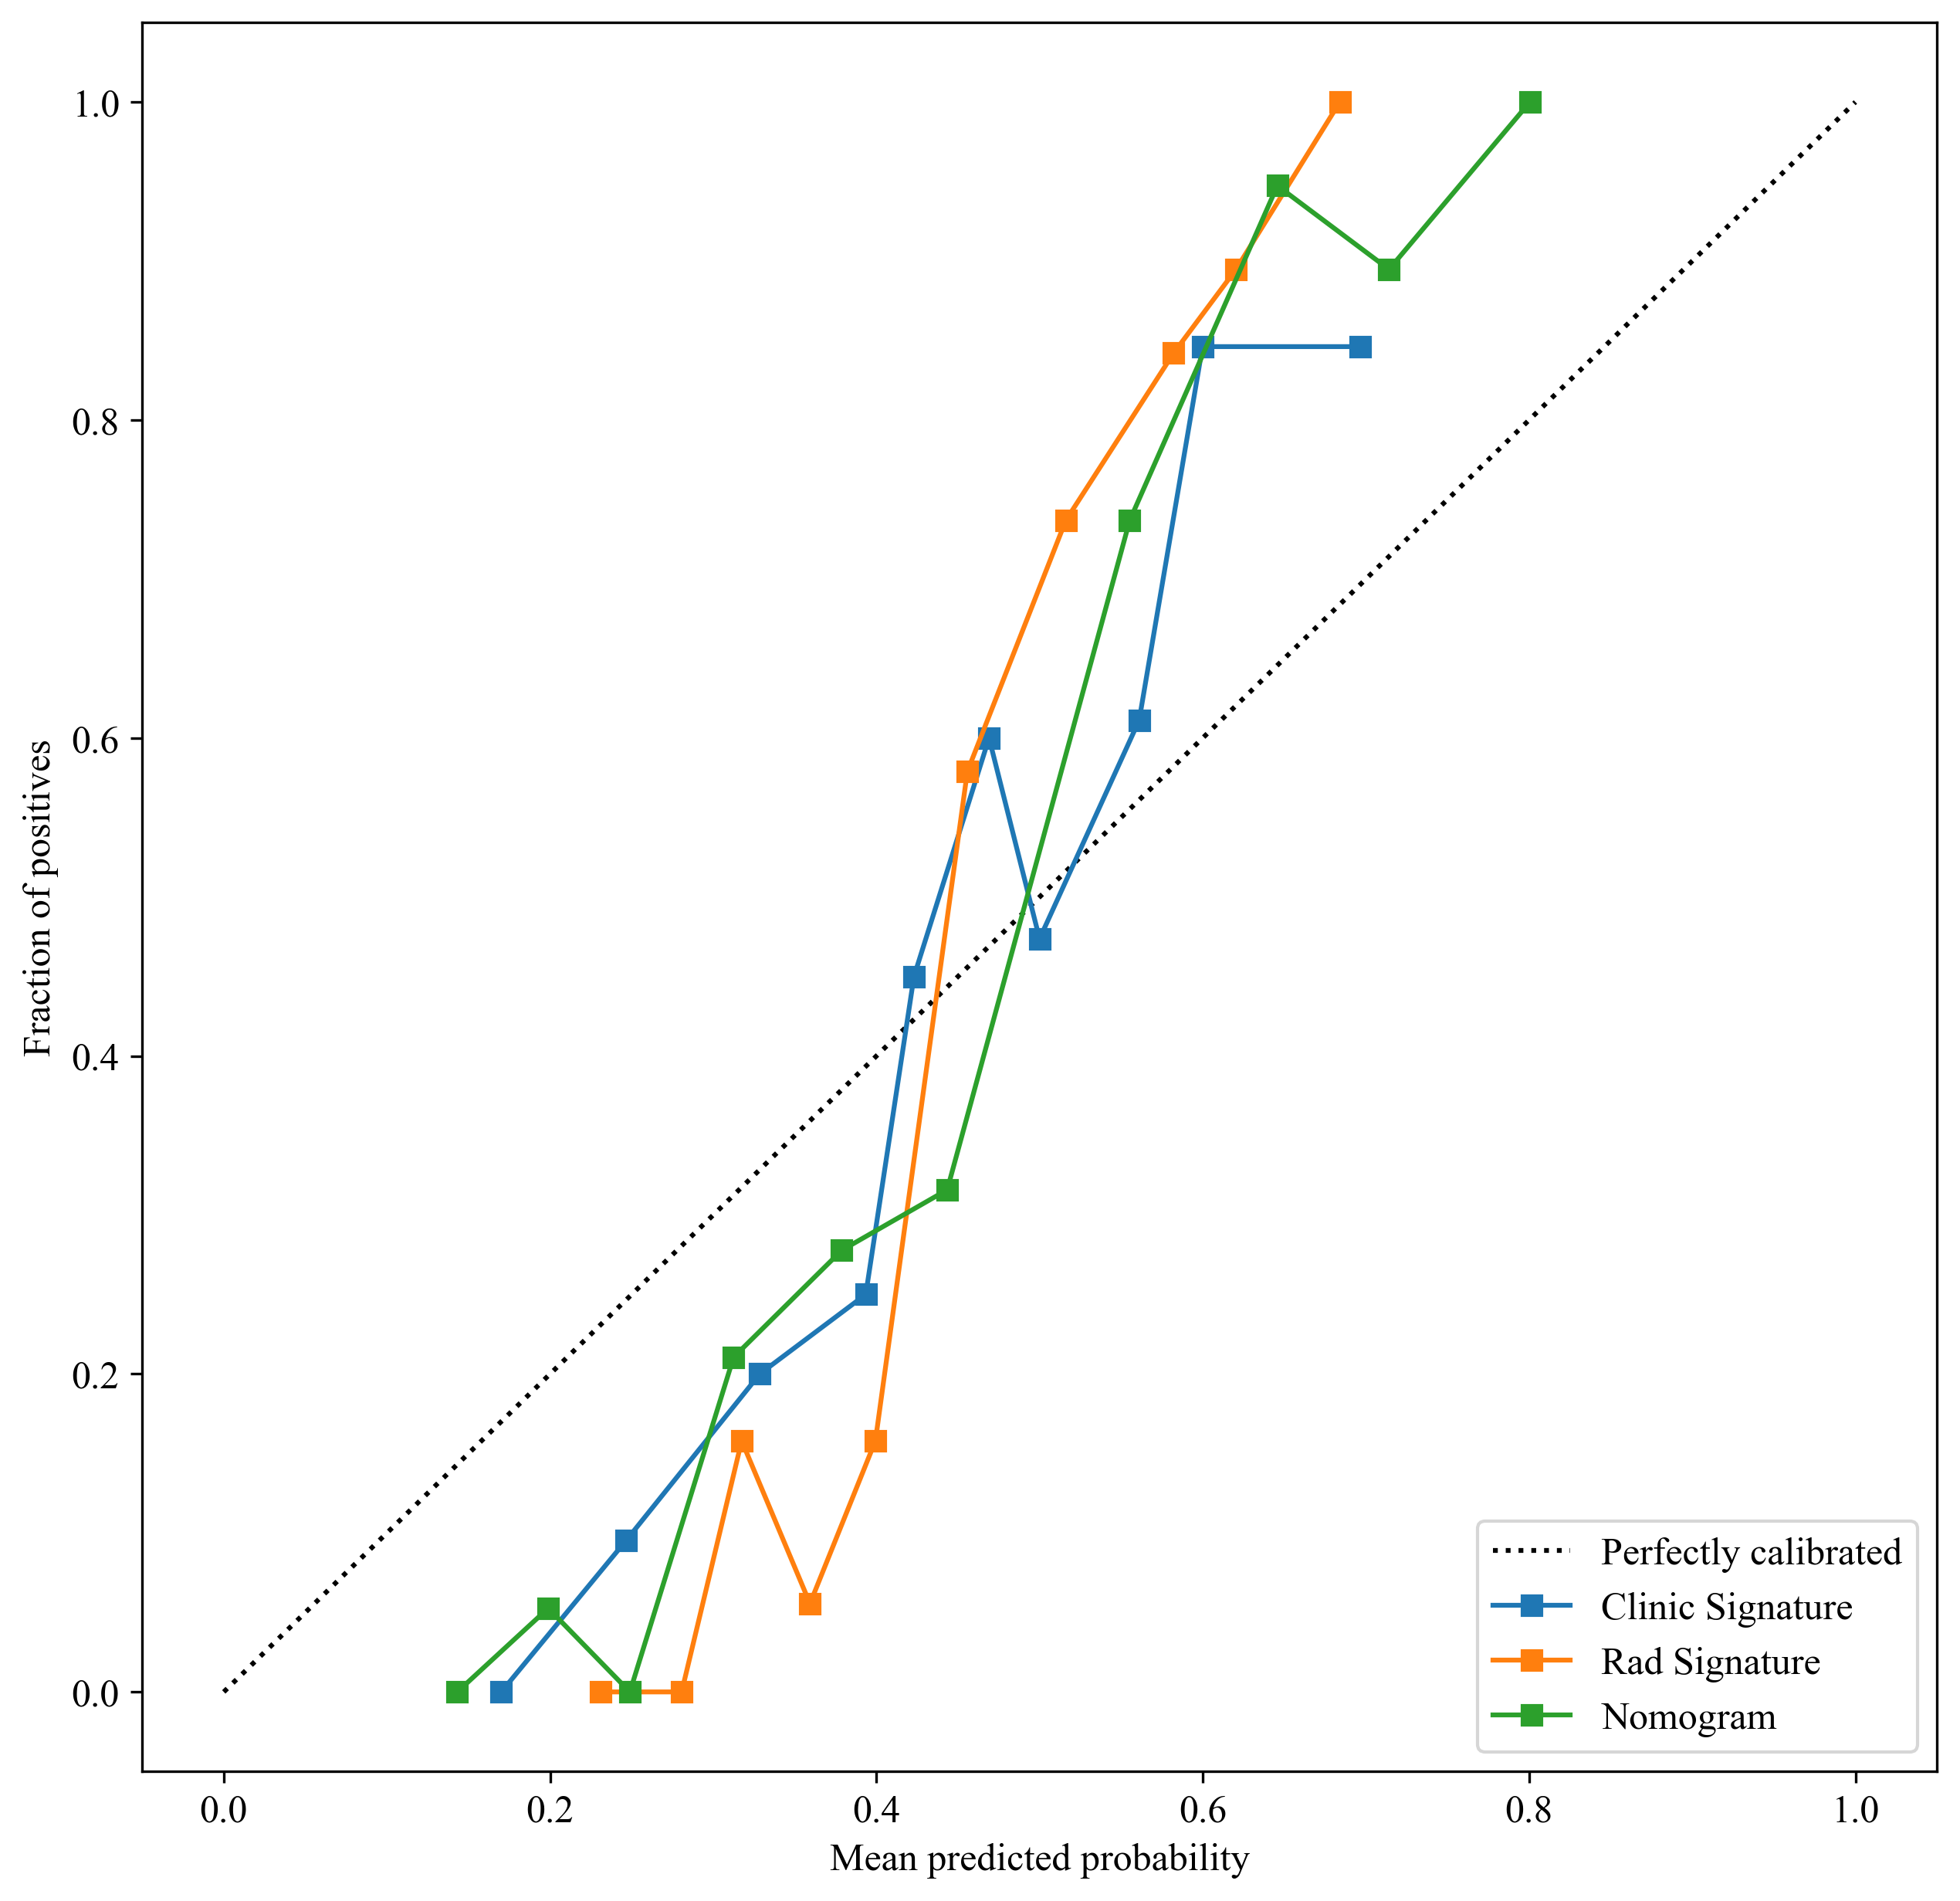

In [8]:
from onekey_algo.custom.components.comp1 import draw_calibration
draw_calibration(pred_scores=pred_train, n_bins=10,
                 y_test=gt, model_names=model_names)
plt.savefig(f'img/train_cali.svg')

In [9]:
from onekey_algo.custom.components import stats

hosmer = []
hosmer.append([stats.hosmer_lemeshow_test(y_true, y_pred[:,1], bins=15) 
              for fn, y_true, y_pred in zip(model_names, gt, pred_train)])
pd.DataFrame(hosmer, columns=model_names)

,Clinic Signature,Rad Signature,Nomogram
0,0.162,3.080e-07,5.022e-04


# 测试集-Nomogram

In [10]:
import pandas as pd

Clinic_results = pd.merge(pd.read_csv(f'./results/Clinic_{bst_model}_test.csv', header=0), label_data, on='ID', how='inner')
Rad_results = pd.merge(pd.read_csv(f'./results/Rad_{bst_model}_test.csv', header=0), label_data, on='ID', how='inner')

ALL_results = pd.merge(Clinic_results, Rad_results, on='ID', how='inner')
ALL_results.columns = ['ID', '-0', 'Clinic_Sig', task, '-00', 'Rad_Sig', '-l']

ALL_results = ALL_results.dropna(axis=1)
ALL_results

,ID,-0,Clinic_Sig,label,-00,Rad_Sig,-l
0,10.nii.gz,0.725,0.275,1,0.276,0.724,1
1,12.nii.gz,0.505,0.495,1,0.607,0.393,1
2,16.nii.gz,0.415,0.585,1,0.421,0.579,1
3,17.nii.gz,0.573,0.427,1,0.428,0.572,1
4,24.nii.gz,0.632,0.368,1,0.298,0.702,1
5,28.nii.gz,0.573,0.427,1,0.412,0.588,1
6,35.nii.gz,0.538,0.462,1,0.416,0.584,1
7,40.nii.gz,0.493,0.507,1,0.593,0.407,1
8,44.nii.gz,0.596,0.404,1,0.472,0.528,1
9,45.nii.gz,0.547,0.453,1,0.593,0.407,1


In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from onekey_algo.custom.components import metrics

model = LogisticRegression(random_state=0)
# model = SVC(probability=True, random_state=0)
data_x = ALL_results[['Clinic_Sig', 'Rad_Sig']]
data_y = ALL_results[task]
model.fit(data_x, data_y)
results = model.predict_proba(data_x)
results = pd.DataFrame(results, index=ALL_results['ID'], columns=[f'{task}-0', f'{task}-1']).reset_index()
results.to_csv('./results/Nomo_test.csv', index=False, header=True)
pd.DataFrame([metrics.analysis_pred_binary(ALL_results[task], results[f'{task}-1'])], 
                  columns=['acc', 'auc', '95%CI', 'Sensitivity', 'Specificity', 'PPV', 'NPV', 'Precision', 'Recall', 'F1', 'Threshold'])

,acc,auc,95%CI,Sensitivity,Specificity,PPV,NPV,Precision,Recall,F1,Threshold
0,0.771,0.83,"[0.710392, 0.950447]",0.909,0.654,0.69,0.895,0.69,0.909,0.784,0.45


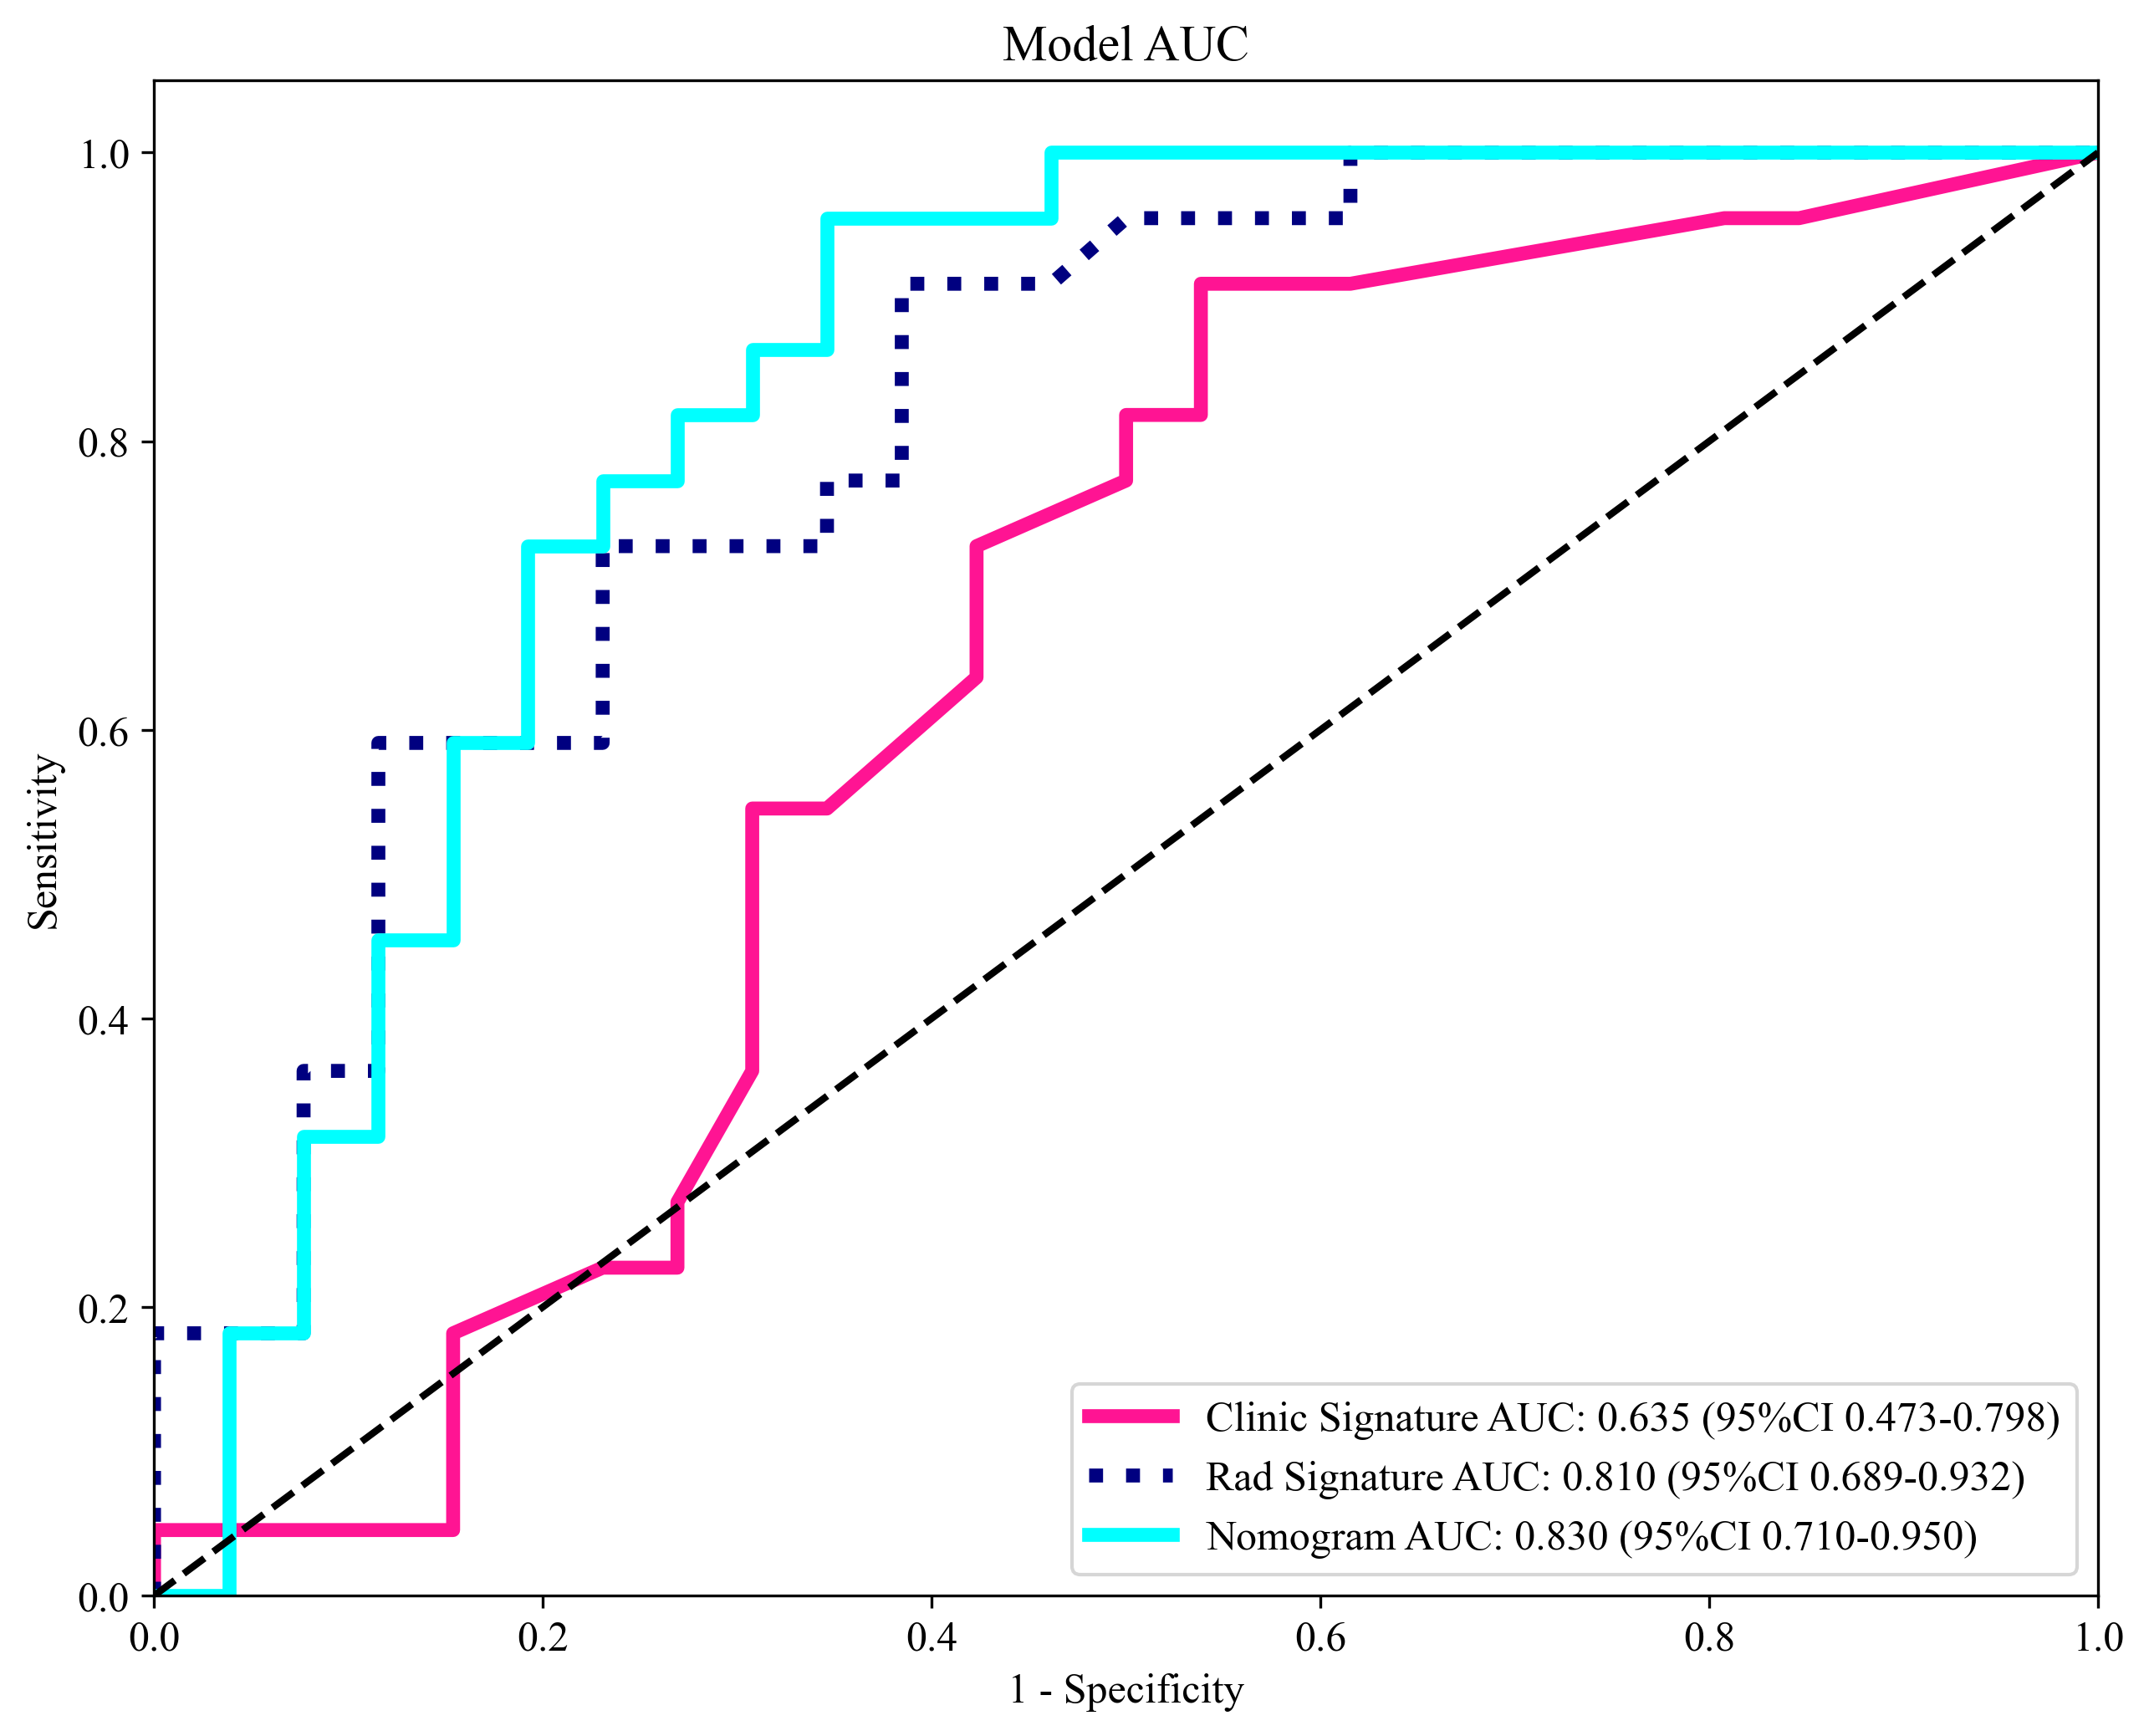

In [12]:
pred_column = [f'{task}-0', f'{task}-1']
Nomo_results = pd.merge(pd.read_csv('./results/Nomo_test.csv', header=0), label_data, on='ID', how='inner')
gt = [np.array(d) for d in [Clinic_results[labels], Rad_results[labels], Nomo_results[labels]]]
pred_train = [np.array(d) for d in [Clinic_results[pred_column], Rad_results[pred_column], Nomo_results[pred_column]]]
okcomp.comp1.draw_roc(gt, pred_train, labels=model_names,  
                      title=f"Model AUC")
plt.savefig(f'img/test_auc.svg')

In [13]:
from onekey_algo.custom.components.metrics import analysis_pred_binary
for mname, y, score in zip(model_names, gt, pred_train):
    # 计算验证集指标
    acc, auc, ci, tpr, tnr, ppv, npv, precision, recall, f1, thres = analysis_pred_binary(y, score)
    ci = f"{ci[0]:.4f} - {ci[1]:.4f}"
    metric.append((mname, acc, auc, ci, tpr, tnr, ppv, npv, precision, recall, f1, thres, f"Test"))
metric = pd.DataFrame(metric, index=None, columns=['Signature', 'Accuracy', 'AUC', '95% CI',
                                                   'Sensitivity', 'Specificity', 
                                                   'PPV', 'NPV', 'Precision', 'Recall', 'F1',
                                                   'Threshold', 'Cohort'])

metric

,Signature,Accuracy,AUC,95% CI,Sensitivity,Specificity,PPV,NPV,Precision,Recall,F1,Threshold,Cohort
0,Clinic Signature,0.725,0.818,0.7591 - 0.8765,0.833,0.638,0.648,0.827,0.648,0.833,0.729,0.413,Train
1,Rad Signature,0.878,0.930,0.8945 - 0.9662,0.893,0.867,0.843,0.910,0.843,0.893,0.867,0.449,Train
2,Nomogram,0.873,0.935,0.9019 - 0.9688,0.821,0.914,0.885,0.865,0.885,0.821,0.852,0.493,Train
3,Clinic Signature,0.625,0.635,0.4730 - 0.7980,0.818,0.462,0.562,0.750,0.562,0.818,0.667,0.368,Test
4,Rad Signature,0.708,0.810,0.6887 - 0.9319,0.818,0.615,0.643,0.800,0.643,0.818,0.720,0.407,Test
5,Nomogram,0.771,0.830,0.7104 - 0.9504,0.909,0.654,0.690,0.895,0.690,0.909,0.784,0.450,Test


In [14]:
from onekey_algo.custom.components.delong import delong_roc_test

Nomo_results.columns = ['ID', '-00000', 'Nomogram', '-llll']
results = pd.merge(ALL_results, Nomo_results, on='ID', how='inner')

delong.append([delong_roc_test(results[task], results[f'Nomogram'], results[f'Clinic_Sig'])[0][0],
              delong_roc_test(results[task], results[f'Nomogram'], results[f'Rad_Sig'])[0][0], 'Test'])
pd.DataFrame(delong, columns=['Nomogram Vs Clinic', 'Nomogram Vs Rad', 'cohort'])

,Nomogram Vs Clinic,Nomogram Vs Rad,cohort
0,8.863e-07,0.620,Train
1,6.823e-03,0.603,Test


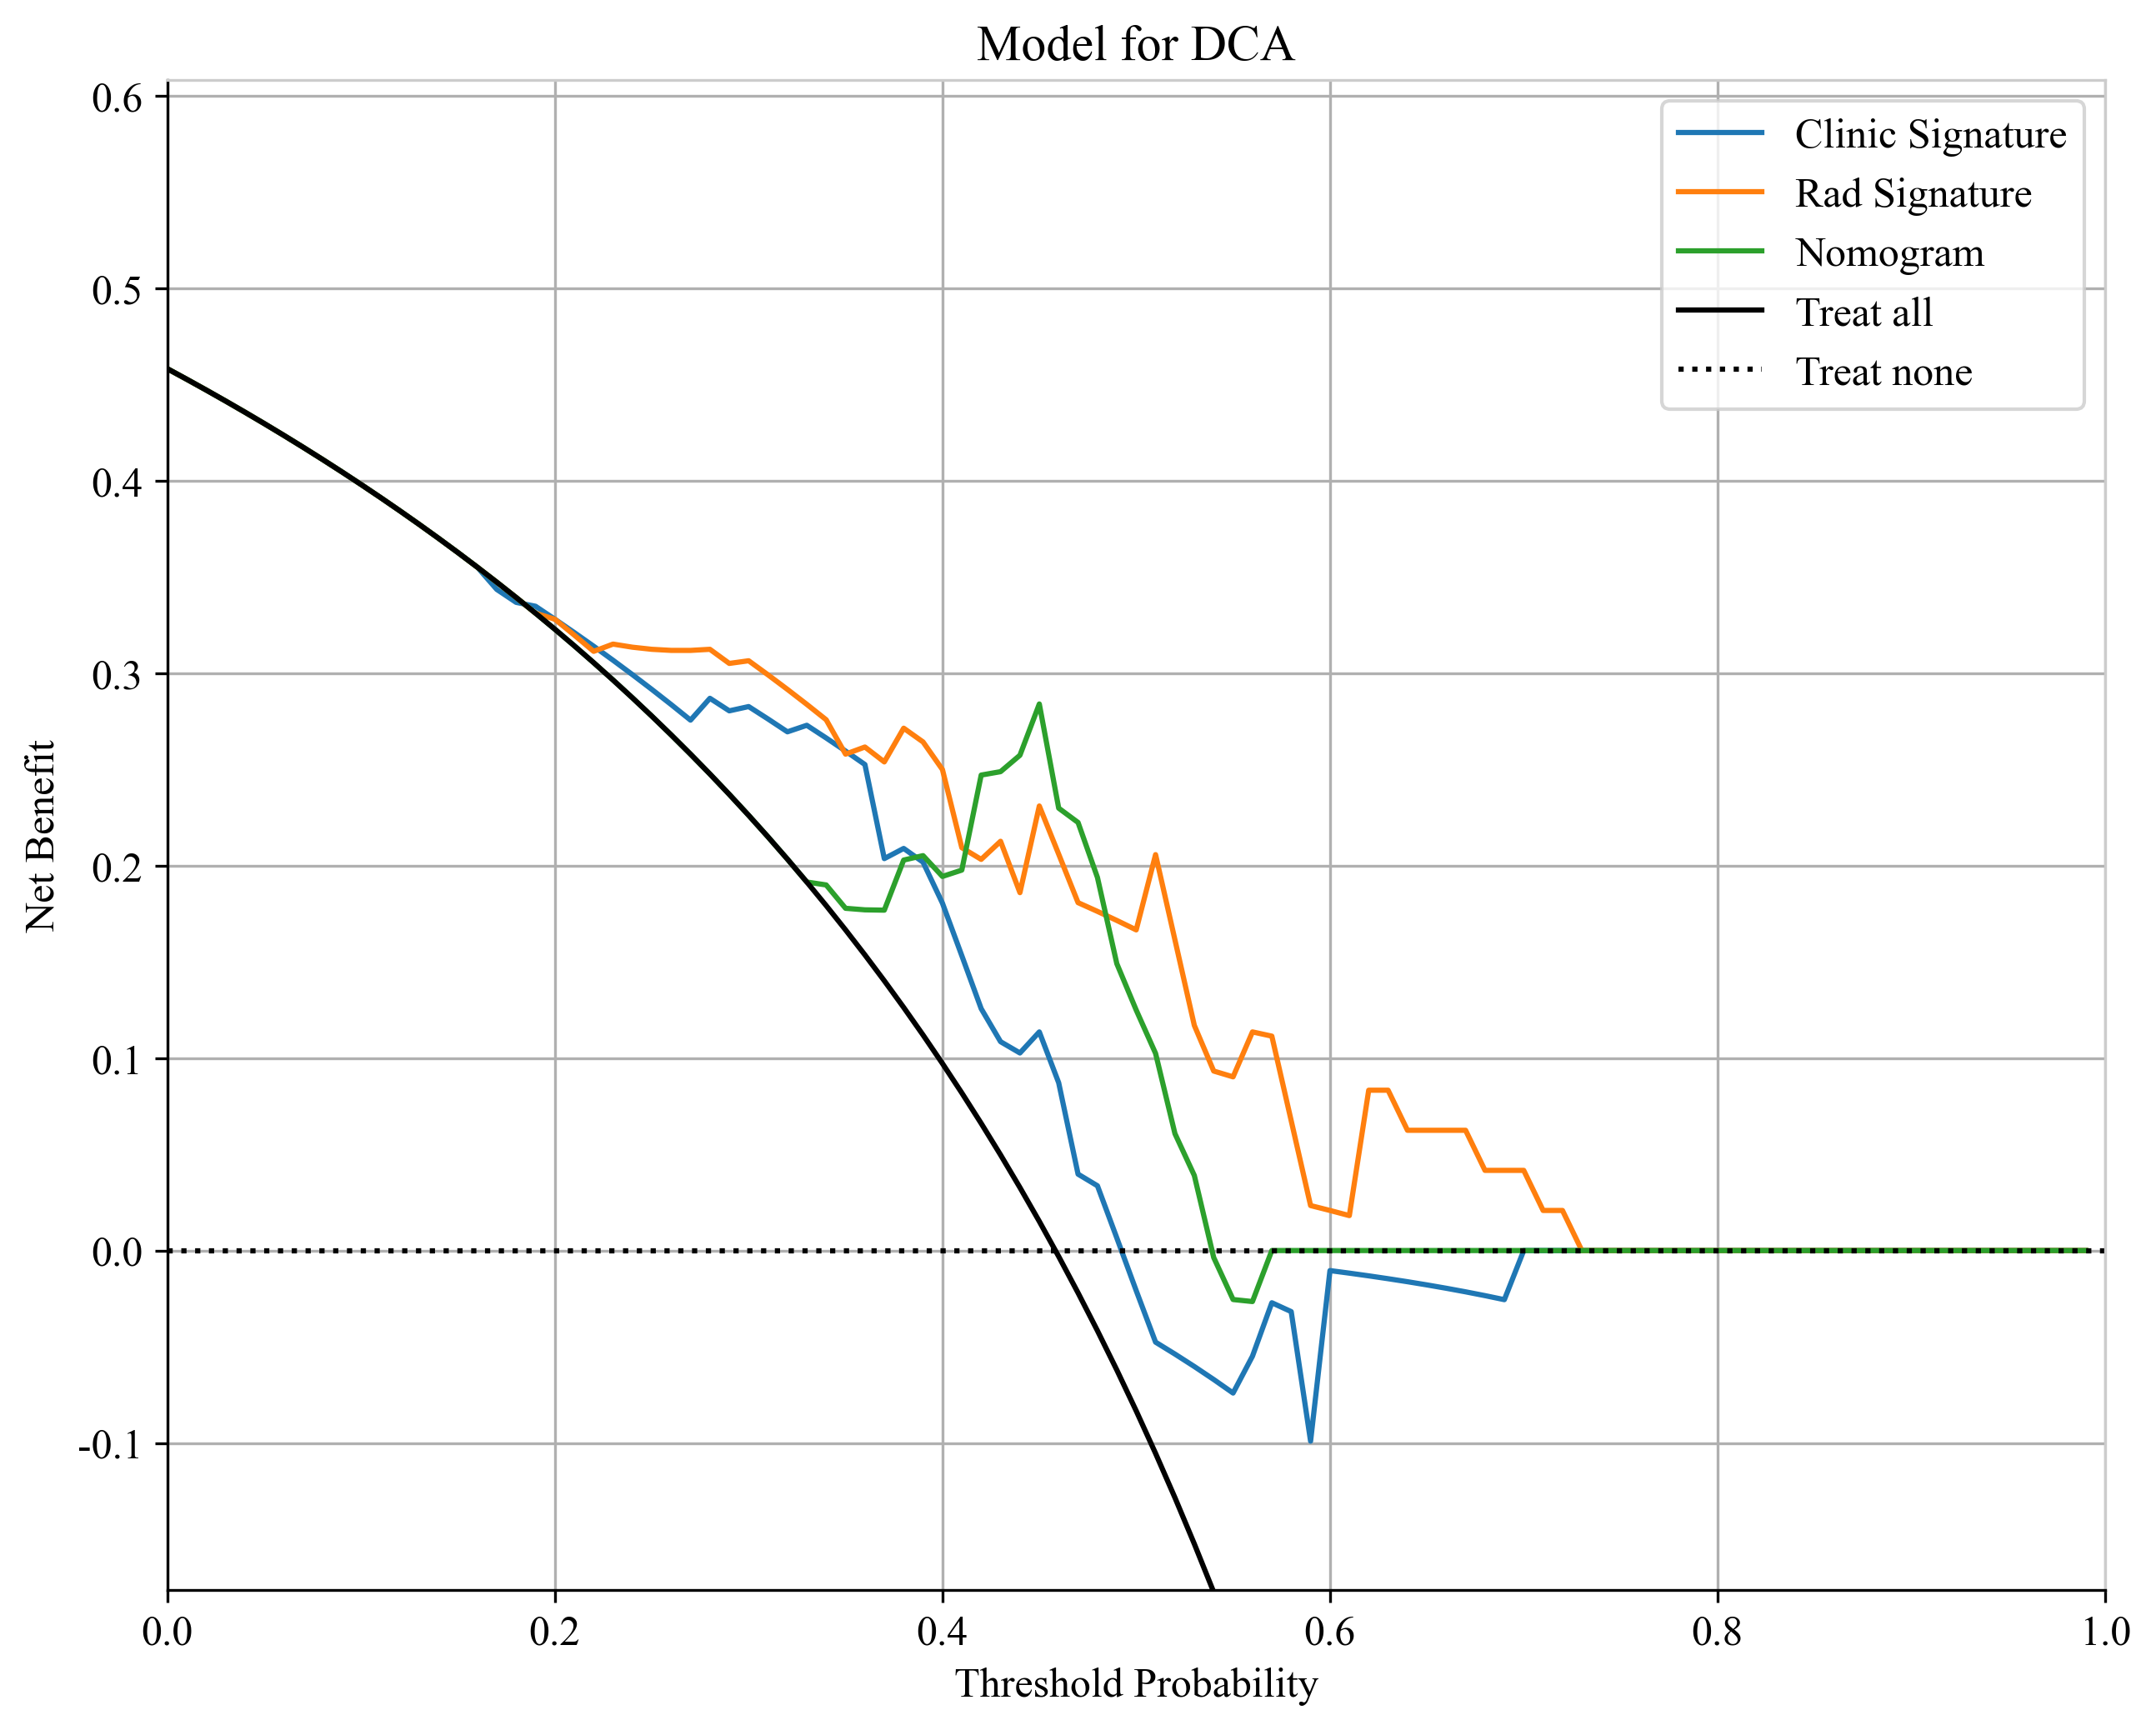

In [15]:
from onekey_algo.custom.components.comp1 import plot_DCA
plot_DCA([results[f'Clinic_Sig'], results[f'Rad_Sig'], results[f'Nomogram']], 
         results[task], title=f'Model for DCA', labels=model_names)
plt.savefig(f'img/test_dca.svg')

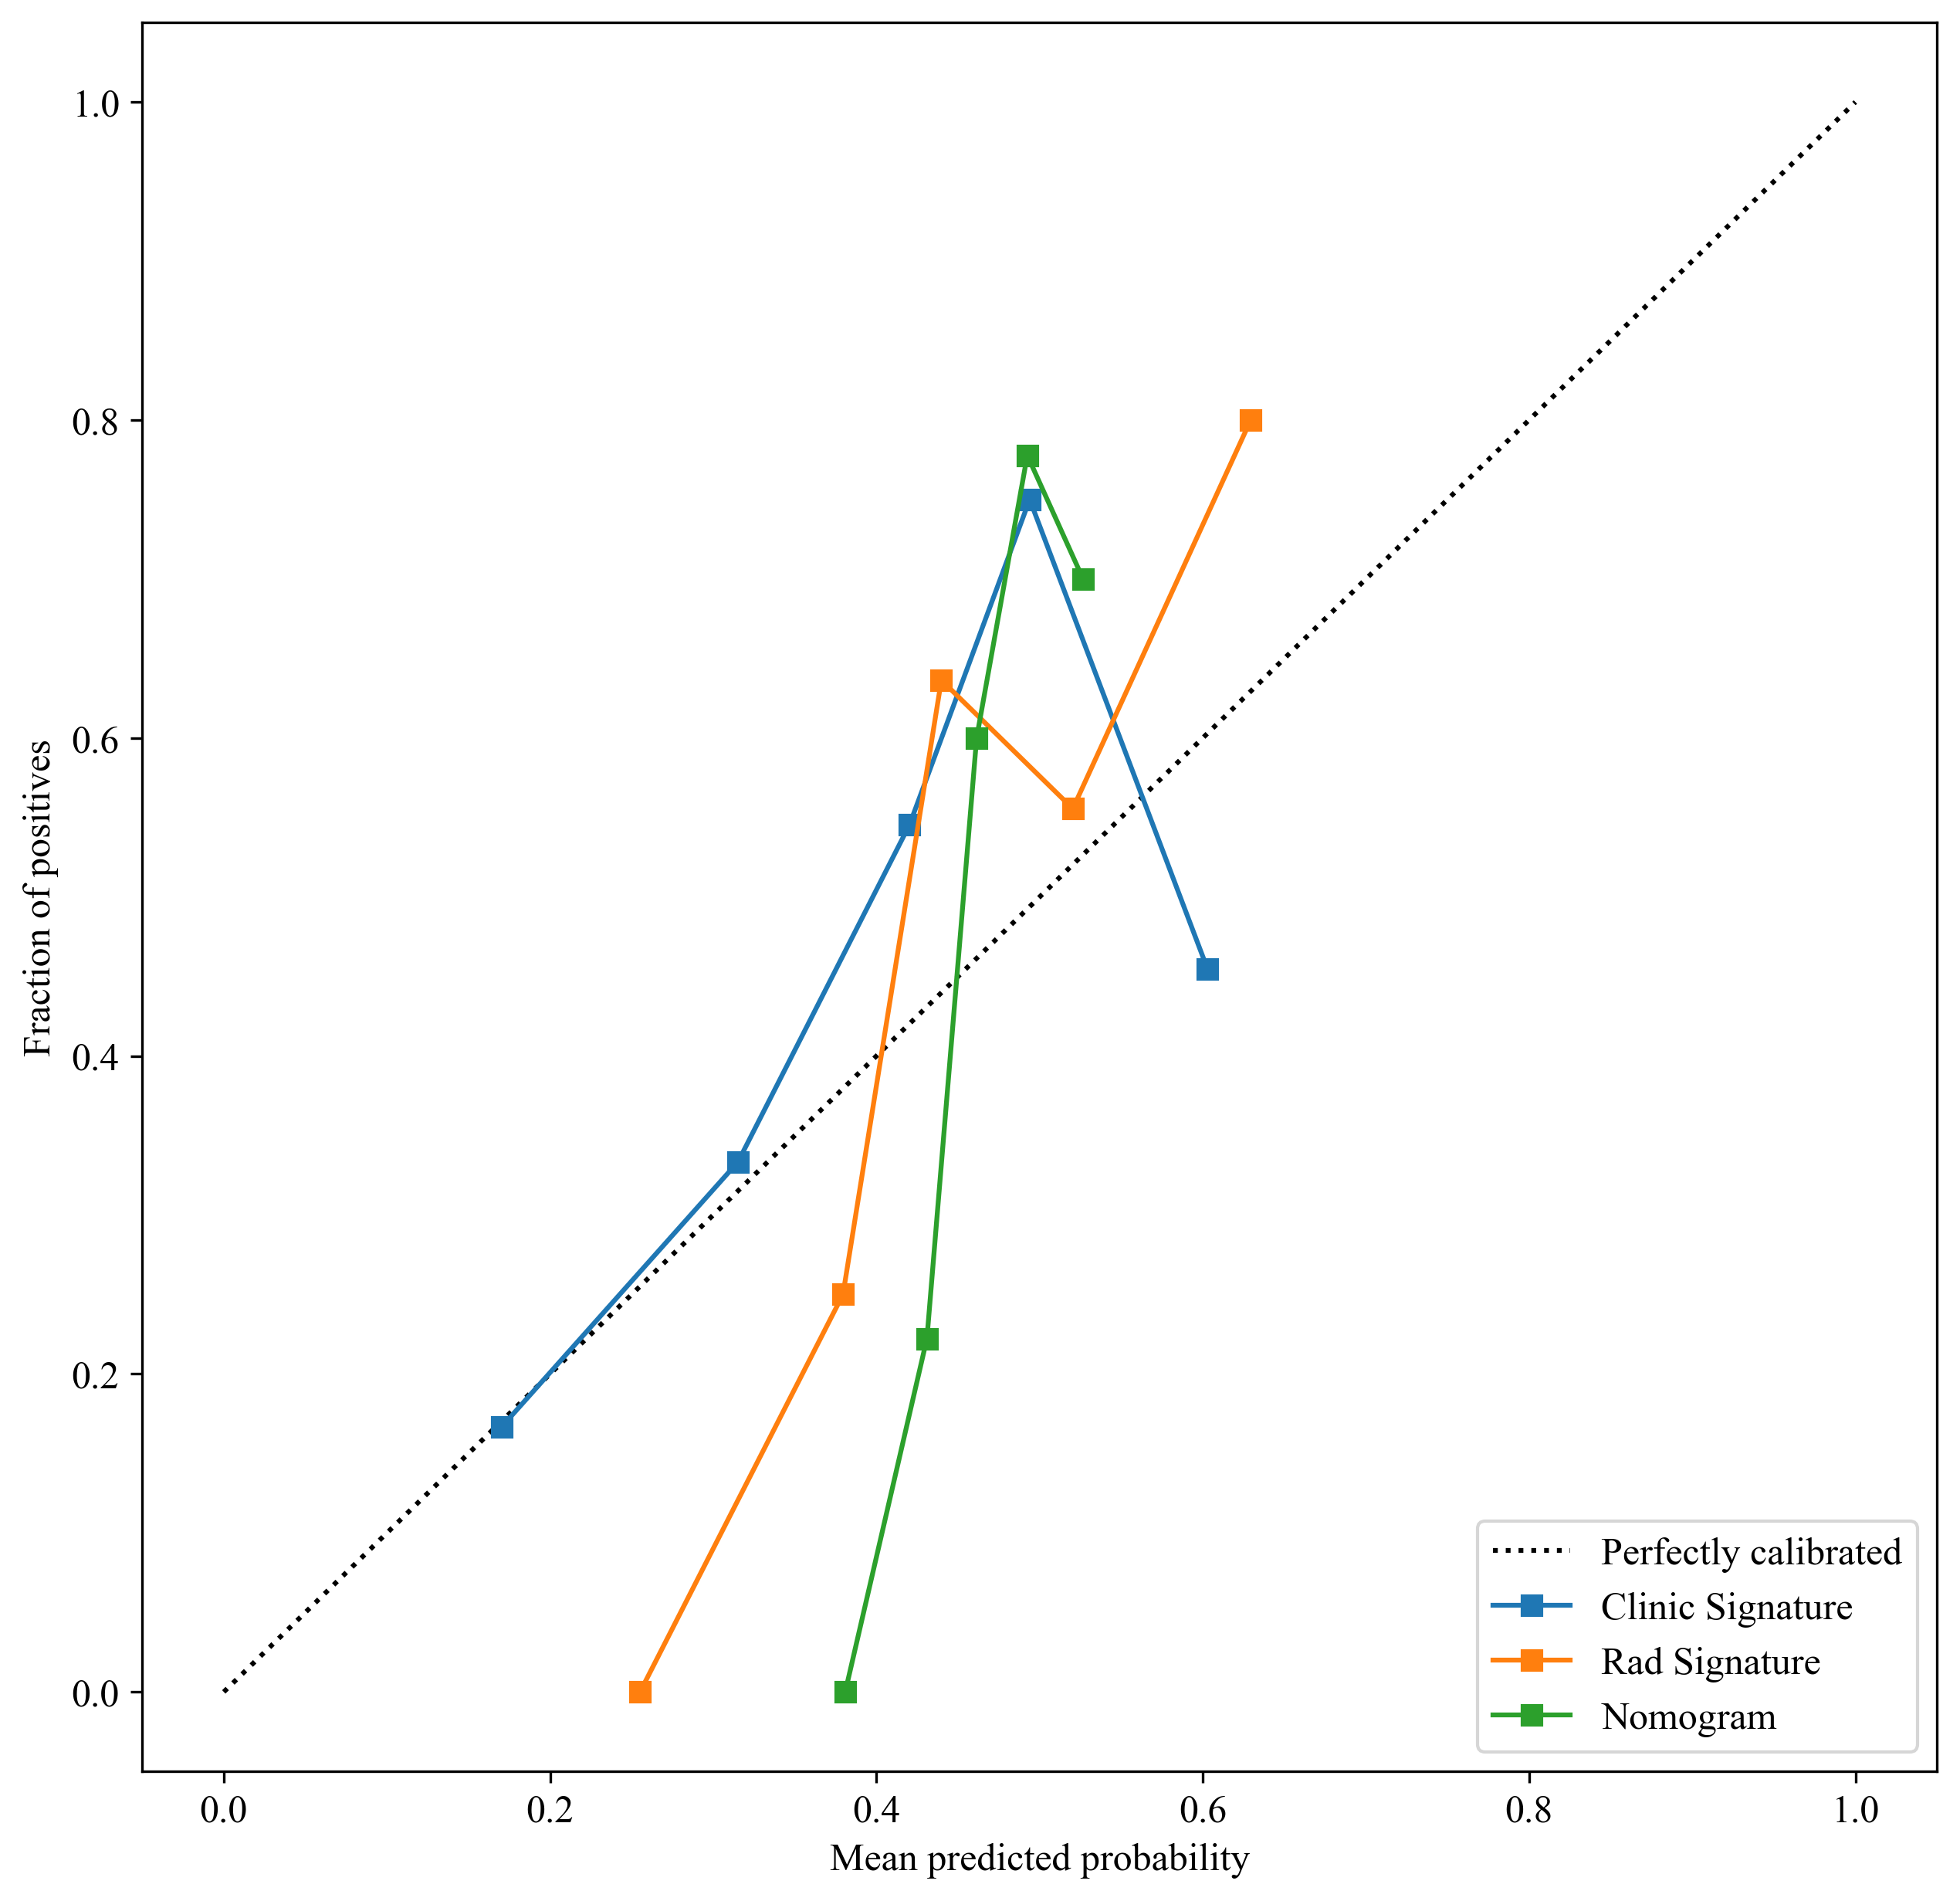

In [16]:
from onekey_algo.custom.components.comp1 import draw_calibration
draw_calibration(pred_scores=pred_train, n_bins=5,
                 y_test=gt, model_names=model_names)
plt.savefig(f'img/test_cali.svg')

In [17]:
from onekey_algo.custom.components import stats

hosmer.append([stats.hosmer_lemeshow_test(y_true, y_pred[:,1], bins=5) 
              for fn, y_true, y_pred in zip(model_names, gt, pred_train)])
pd.DataFrame(hosmer, columns=model_names)

,Clinic Signature,Rad Signature,Nomogram
0,0.162,3.080e-07,5.022e-04
1,0.418,1.608e-01,5.432e-03


[2024-10-31 14:56:41 - situation.py:  45]	INFO	cffi mode is CFFI_MODE.ANY
[2024-10-31 14:56:41 - situation.py: 189]	INFO	R home found: G:\\onekey_envs\Lib\R
[2024-10-31 14:56:42 - situation.py: 136]	ERROR	Unable to determine R library path: Command '('G:\\\\onekey_envs\\Lib\\R\\bin\\Rscript', '-e', 'cat(Sys.getenv("LD_LIBRARY_PATH"))')' returned non-zero exit status 1.
[2024-10-31 14:56:42 - situation.py: 147]	INFO	LD_LIBRARY_PATH: 
[2024-10-31 14:56:42 - embedded.py:  20]	INFO	Default options to initialize R: rpy2, --quiet, --no-save


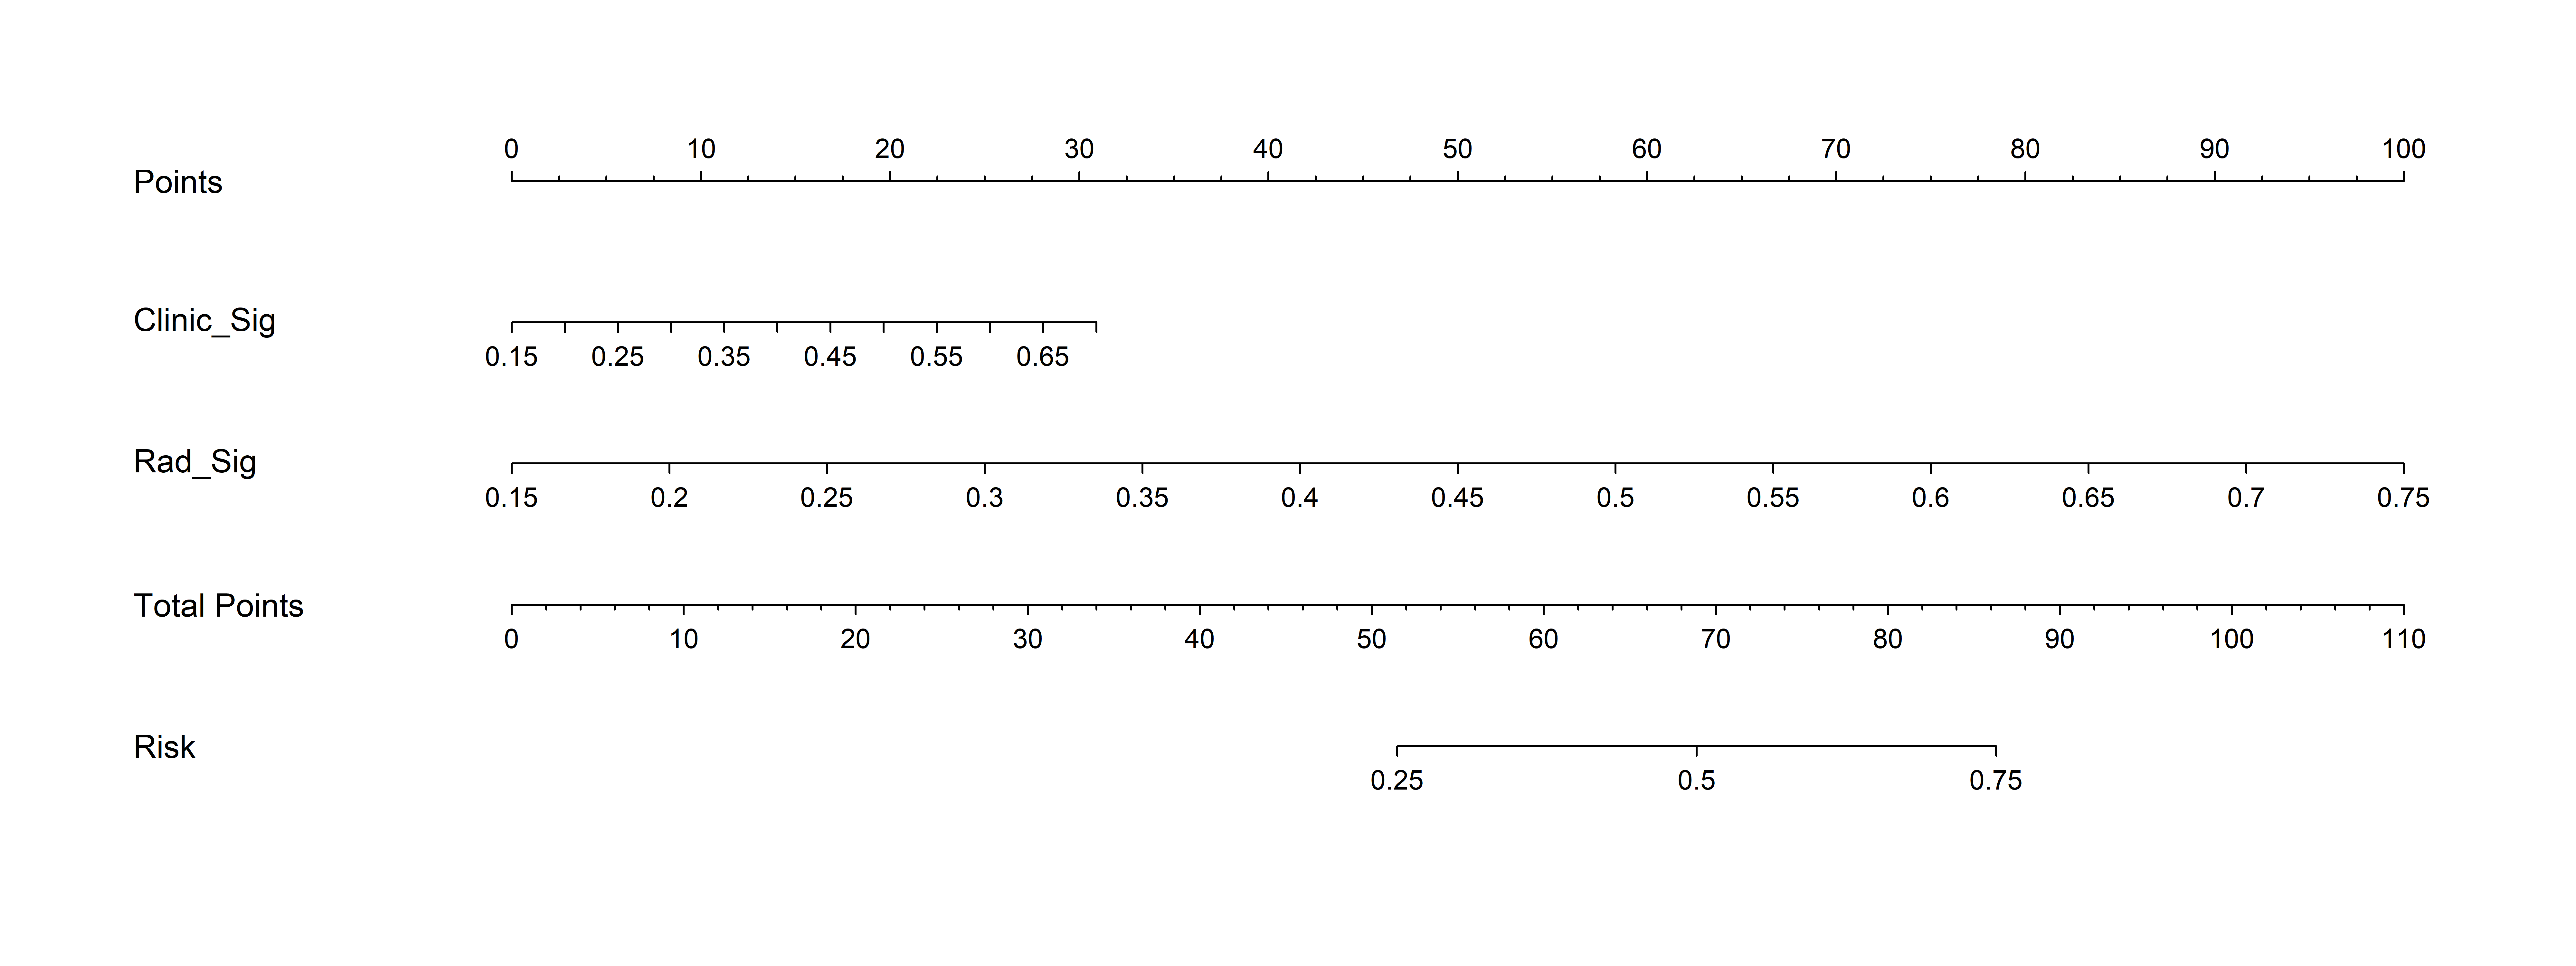

In [18]:
from onekey_algo.custom.components import nomogram
import shutil

nomogram.risk_nomogram(ALL_results, result=task, columns=['Clinic_Sig', 'Rad_Sig'], width=8000, height=3000,
                      x_range='0.01,0.25,0.5,0.75,0.99')